In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import glob

data_path = "/content/drive/MyDrive/DATASETS FINAL PROJECT/Data/"

files = glob.glob(data_path + "*.csv")

files

['/content/drive/MyDrive/DATASETS FINAL PROJECT/Data/E0 (1).csv',
 '/content/drive/MyDrive/DATASETS FINAL PROJECT/Data/E0 (2).csv',
 '/content/drive/MyDrive/DATASETS FINAL PROJECT/Data/E0 (3).csv']

In [4]:
df_list = []

for file in files:
    data = pd.read_csv(file)
    df_list.append(data)

df = pd.concat(df_list, ignore_index=True)

print("Combined dataset size:", df.shape)
df.head(400)

Combined dataset size: (1060, 162)


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,IWA,VCH,VCD,VCA,IWCH,IWCD,IWCA,VCCH,VCCD,VCCA
0,E0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,16/08/2025,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,16/08/2025,15:00,Brighton,Fulham,1,1,D,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,16/08/2025,15:00,Sunderland,West Ham,3,0,H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,16/08/2025,15:00,Tottenham,Burnley,3,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,E0,02/11/2024,15:00,Southampton,Everton,1,0,H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
396,E0,02/11/2024,17:30,Wolves,Crystal Palace,2,2,D,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397,E0,03/11/2024,14:00,Tottenham,Aston Villa,4,1,H,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
398,E0,03/11/2024,16:30,Man United,Chelsea,1,1,D,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:

columns_needed = [
    "Date",
    "HomeTeam",
    "AwayTeam",
    "FTHG",
    "FTAG",
    "FTR",
    "HS",
    "AS",
    "HST",
    "AST",
    "HF",
    "AF",
    "HY",
    "AY"
]

df = df[columns_needed]

df.head(50)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,HF,AF,HY,AY
0,15/08/2025,Liverpool,Bournemouth,4,2,H,19,10,10,3,7,10,1,2
1,16/08/2025,Aston Villa,Newcastle,0,0,D,3,16,3,3,13,11,1,1
2,16/08/2025,Brighton,Fulham,1,1,D,10,7,4,2,16,15,3,3
3,16/08/2025,Sunderland,West Ham,3,0,H,10,12,5,4,8,10,0,1
4,16/08/2025,Tottenham,Burnley,3,0,H,16,14,6,4,14,8,0,0
5,16/08/2025,Wolves,Man City,0,4,A,9,15,3,4,13,7,1,2
6,17/08/2025,Chelsea,Crystal Palace,0,0,D,19,12,3,4,10,12,2,3
7,17/08/2025,Nott'm Forest,Brentford,3,1,H,11,10,5,3,7,15,1,2
8,17/08/2025,Man United,Arsenal,0,1,A,22,9,7,3,10,19,1,4
9,18/08/2025,Leeds,Everton,1,0,H,21,7,3,1,6,8,0,2


In [6]:
df.isnull().sum()

,0
Date,0
HomeTeam,0
AwayTeam,0
FTHG,0
FTAG,0
FTR,0
HS,0
AS,0
HST,0
AST,0


In [ ]:
df["Date"]=pd.to_datetime(df["Date"], dayfirst= True, errors="coerce")
df=df.sort_values("Date").copy()

In [7]:
df=df.dropna()

In [8]:
## NEW PERFORMANCE FEATURES ##


df["Goal Difference"] = df["FTHG"]-df["FTAG"]

df["Shot Difference"]= df["HS"]-df["AS"]

df["Shot target Difference"]= df["HST"]-df["AST"]

df["Foul Difference"]= df["HF"]-df["AF"]

df["Yellow Card Differene"]= df["HY"]-df["AY"]





In [9]:
df["Home Win"]= (df["FTR"]== "H").astype(int)

In [10]:
df["Home Win"].value_counts()

,count
Home Win,
0,605
1,455


In [11]:
df.groupby("HomeTeam")["Home Win"].sum()

,Home Win
HomeTeam,
Arsenal,38
Aston Villa,32
Bournemouth,21
Brentford,21
Brighton,22
Burnley,4
Chelsea,29
Crystal Palace,17
Everton,18


In [12]:
df["HomeTeam"].value_counts()

,count
HomeTeam,
Wolves,54
Liverpool,53
Aston Villa,53
Tottenham,53
Brighton,53
Nott'm Forest,53
Chelsea,53
Man United,53
West Ham,53


In [13]:
### VERY IMPORTANT FACTOR FOR A TEAMS OVERALL PERFORMANCE
df["xG_home"] = (df["HST"] * 0.4) + ((df["HS"] - df["HST"]) * 0.03)

df.groupby("HomeTeam")["xG_home"].mean()

,xG_home
HomeTeam,
Arsenal,2.667547
Aston Villa,2.387547
Bournemouth,2.330755
Brentford,2.148846
Brighton,2.405849
Burnley,1.624118
Chelsea,2.701887
Crystal Palace,2.125849
Everton,2.012453


In [14]:

df["xG_away"] = (df["AST"] * 0.4) + ((df["AS"] - df["AST"]) * 0.03)
df.groupby("AwayTeam")["xG_away"].mean()

,xG_away
AwayTeam,
Arsenal,2.194815
Aston Villa,1.795849
Bournemouth,2.248491
Brentford,1.883208
Brighton,2.130189
Burnley,1.495294
Chelsea,2.186604
Crystal Palace,1.861698
Everton,1.538868


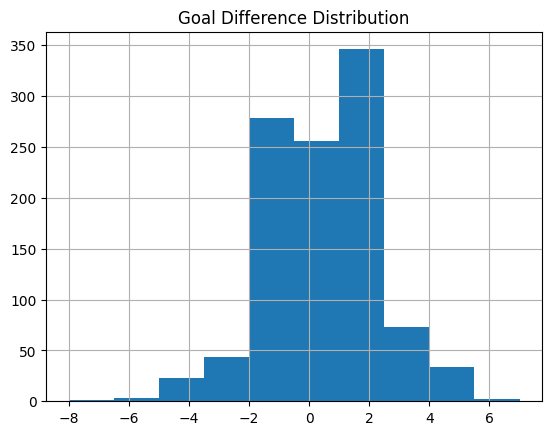

In [15]:
import matplotlib.pyplot as plt

df["Goal Difference"].hist()
plt.title("Goal Difference Distribution")
plt.show()

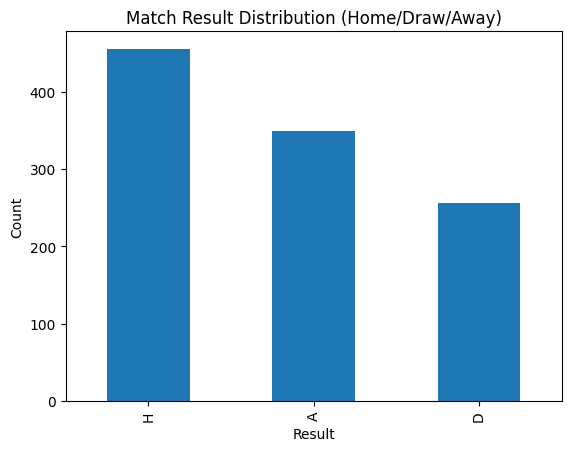

In [16]:
df["FTR"].value_counts().plot(kind="bar")

plt.title("Match Result Distribution (Home/Draw/Away)")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()

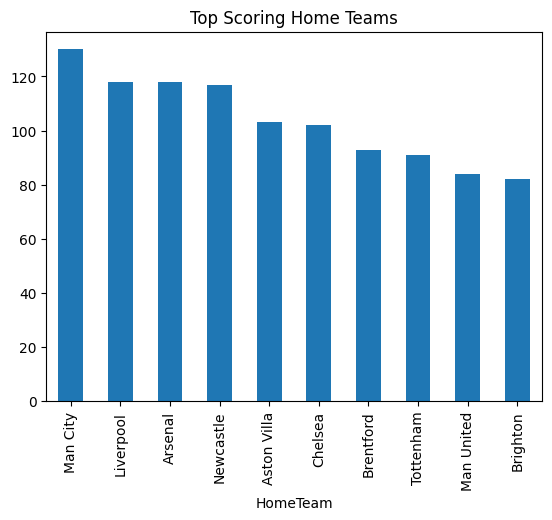

In [17]:
home_goals = df.groupby("HomeTeam")["FTHG"].sum()
home_goals.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top Scoring Home Teams")
plt.show()

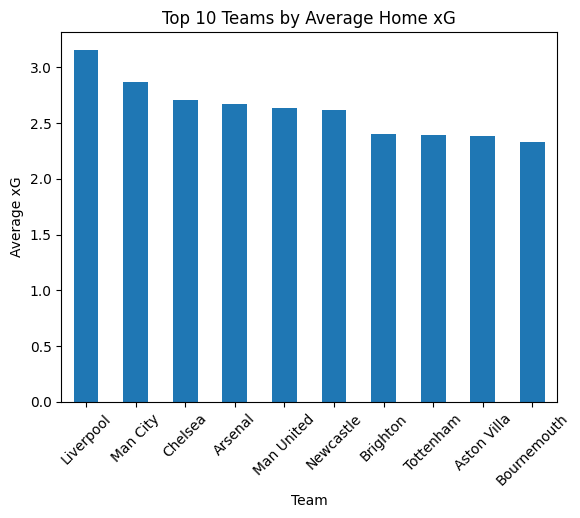

In [18]:

### Average xG of away teams (TOP 10 teams) ##

avg_xG_home = df.groupby("HomeTeam")["xG_home"].mean()

avg_xG_home.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Teams by Average Home xG")
plt.xlabel("Team")
plt.ylabel("Average xG")
plt.xticks(rotation=45)
plt.show()

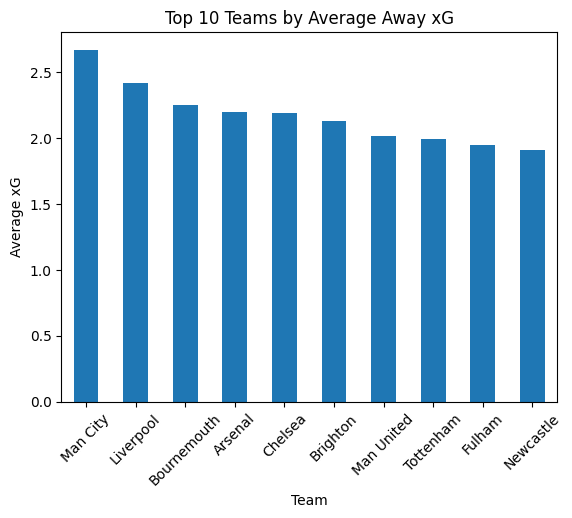

In [19]:

#### AVERAGE XG OF AWAY TEAMS (top 10 ) ######


avg_xG_away = df.groupby("AwayTeam")["xG_away"].mean()

avg_xG_away.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Teams by Average Away xG")
plt.xlabel("Team")
plt.ylabel("Average xG")
plt.xticks(rotation=45)
plt.show()

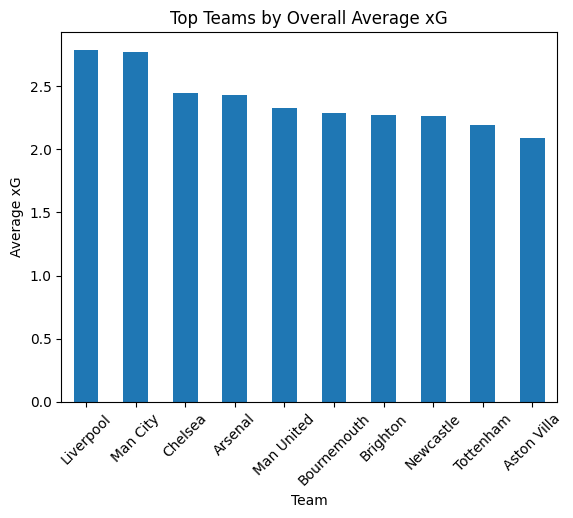

In [20]:
###COMBINING HOME and AWAY xG ###


home = df.groupby("HomeTeam")["xG_home"].mean()
away = df.groupby("AwayTeam")["xG_away"].mean()

total_xg = (home + away) / 2

total_xg.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top Teams by Overall Average xG")
plt.xlabel("Team")
plt.ylabel("Average xG")
plt.xticks(rotation=45)
plt.show()

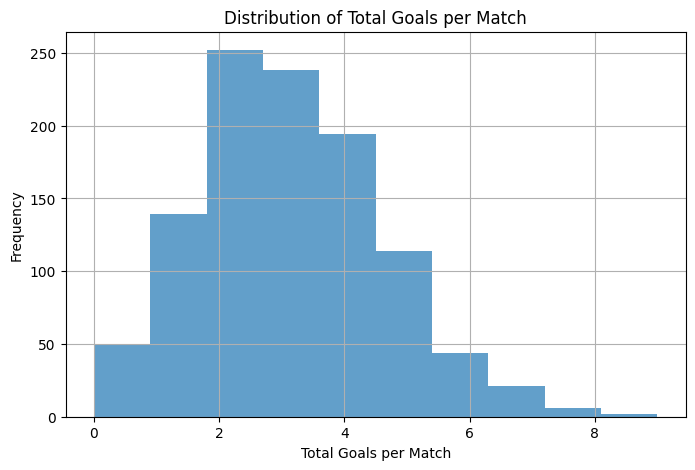

In [21]:
df["total_goals"] = df["FTHG"] + df["FTAG"]

plt.figure(figsize=(8, 5))
plt.hist(df["total_goals"], bins=10, alpha=0.7)
plt.xlabel("Total Goals per Match")
plt.ylabel("Frequency")
plt.title("Distribution of Total Goals per Match")
plt.grid(True)
plt.show()

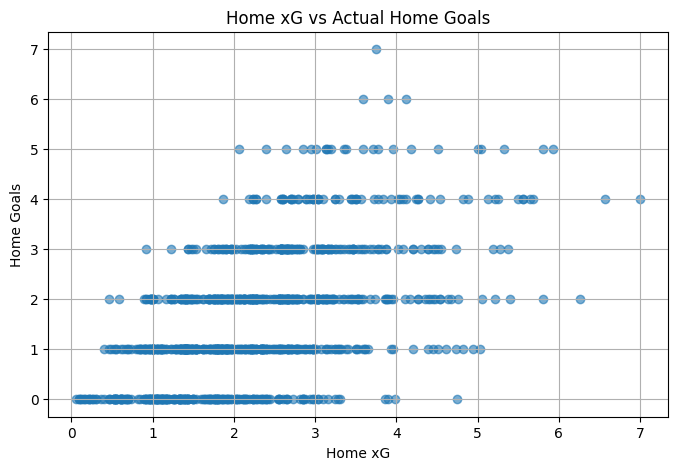

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(df["xG_home"], df["FTHG"], alpha=0.6)
plt.xlabel("Home xG")
plt.ylabel("Home Goals")
plt.title("Home xG vs Actual Home Goals")
plt.grid(True)
plt.show()

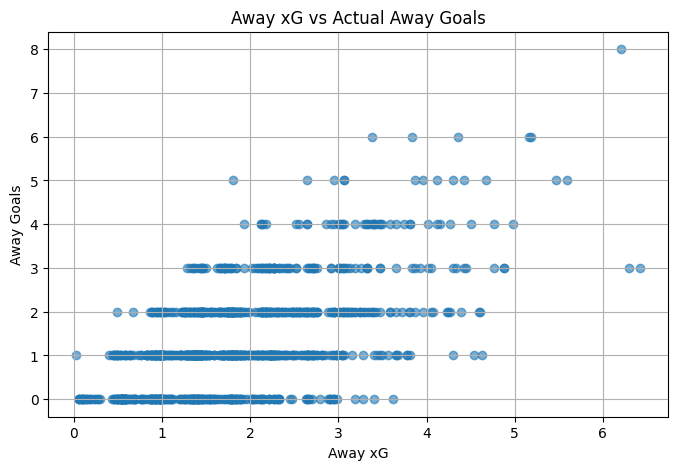

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(df["xG_away"], df["FTAG"], alpha=0.6)
plt.xlabel("Away xG")
plt.ylabel("Away Goals")
plt.title("Away xG vs Actual Away Goals")
plt.grid(True)
plt.show()

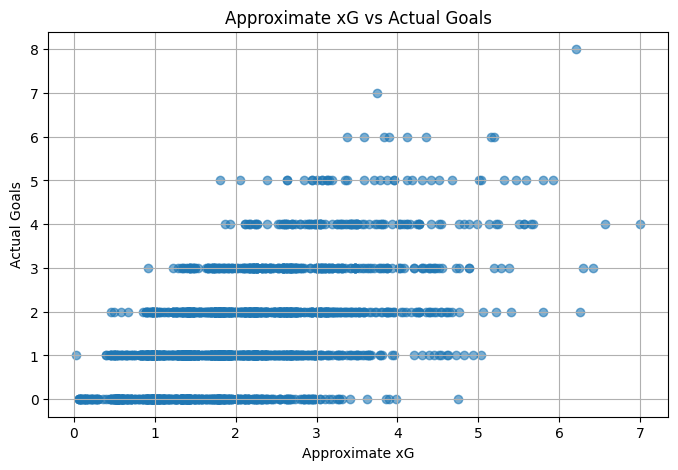

In [24]:
home_plot = df[["xG_home", "FTHG"]].copy()
home_plot.columns = ["xG", "Goals"]

away_plot = df[["xG_away", "FTAG"]].copy()
away_plot.columns = ["xG", "Goals"]

xg_goal_plot = pd.concat([home_plot, away_plot], ignore_index=True)

plt.figure(figsize=(8, 5))
plt.scatter(xg_goal_plot["xG"], xg_goal_plot["Goals"], alpha=0.6)
plt.xlabel("Approximate xG")
plt.ylabel("Actual Goals")
plt.title("Approximate xG vs Actual Goals")
plt.grid(True)
plt.show()

In [25]:
###  MACHINE LEARNING CODE - START ###


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [26]:
import os

os.makedirs("/content/drive/MyDrive/football_analytics_project", exist_ok=True)

In [27]:
df.to_csv("/content/drive/MyDrive/football_analytics_project/epl_clean_dataset.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [28]:
df = pd.read_csv("/content/drive/MyDrive/football_analytics_project/epl_clean_dataset.csv")
df = df.copy()
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,...,AY,Goal Difference,Shot Difference,Shot target Difference,Foul Difference,Yellow Card Differene,Home Win,xG_home,xG_away,total_goals
0,15/08/2025,Liverpool,Bournemouth,4,2,H,19,10,10,3,...,2,2,9,7,-3,-1,1,4.27,1.41,6
1,16/08/2025,Aston Villa,Newcastle,0,0,D,3,16,3,3,...,1,0,-13,0,2,0,0,1.20,1.59,0
2,16/08/2025,Brighton,Fulham,1,1,D,10,7,4,2,...,3,0,3,2,1,0,0,1.78,0.95,2
3,16/08/2025,Sunderland,West Ham,3,0,H,10,12,5,4,...,1,3,-2,1,-2,-1,1,2.15,1.84,3
4,16/08/2025,Tottenham,Burnley,3,0,H,16,14,6,4,...,0,3,2,2,6,0,1,2.70,1.90,3


In [29]:
df["Date"]=pd.to_datetime(df["Date"], dayfirst= True, errors="coerce")
df=df.sort_values("Date").copy()

In [30]:
### CORE FEATURES


df["xG_home"] = (df["HST"] * 0.4) + ((df["HS"] - df["HST"]) * 0.03)
df["xG_away"] = (df["AST"] * 0.4) + ((df["AS"] - df["AST"]) * 0.03)

df["shot_acc_home"]= df["HST"]/df["HS"]
df["shot acc_home"]= df["AST"]/df["AS"]

df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)


df["XG Difference"]= df["xG_home"]-df["xG_away"]

df["Goal Difference"] = df["FTHG"]-df["FTAG"]

df["Shot Difference"]= df["HS"]-df["AS"]

df["Shot target Difference"]= df["HST"]-df["AST"]

df["Foul Difference"]= df["HF"]-df["AF"]

df["Yellow Card Differene"]= df["HY"]-df["AY"]




## TARGET VARIABLE
y = df["FTR"]








In [31]:
## DEFINING THE FEATURES

features = [
    "xG_home",
    "xG_away",
    "XG Difference",
    "Shot Difference",
    "Shot target Difference",
    "Foul Difference",
    "Yellow Card Differene"
]

X = df[features]



In [32]:
#### ENCODING THE TARGET VARIABLE

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['A' 'D' 'H']


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [34]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Logistic Regression Accuracy: 0.5990566037735849
              precision    recall  f1-score   support

           A       0.56      0.69      0.62        70
           D       0.50      0.12      0.19        51
           H       0.63      0.80      0.71        91

    accuracy                           0.60       212
   macro avg       0.57      0.54      0.51       212
weighted avg       0.58      0.60      0.55       212



In [35]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Accuracy: 0.5283018867924528
              precision    recall  f1-score   support

           A       0.51      0.51      0.51        70
           D       0.33      0.31      0.32        51
           H       0.65      0.66      0.65        91

    accuracy                           0.53       212
   macro avg       0.50      0.50      0.50       212
weighted avg       0.53      0.53      0.53       212



In [36]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.599057
1,Random Forest,0.528302


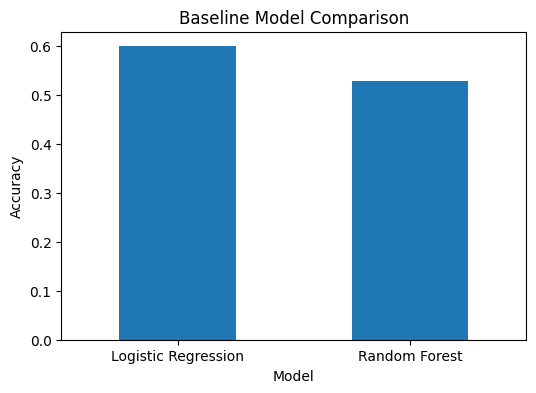

In [37]:
results.plot(x="Model", y="Accuracy", kind="bar", legend=False, figsize=(6,4))
plt.title("Baseline Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

In [38]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp

,0
XG Difference,0.186848
xG_home,0.173891
xG_away,0.160428
Shot Difference,0.137727
Foul Difference,0.128792
Shot target Difference,0.114528
Yellow Card Differene,0.097786


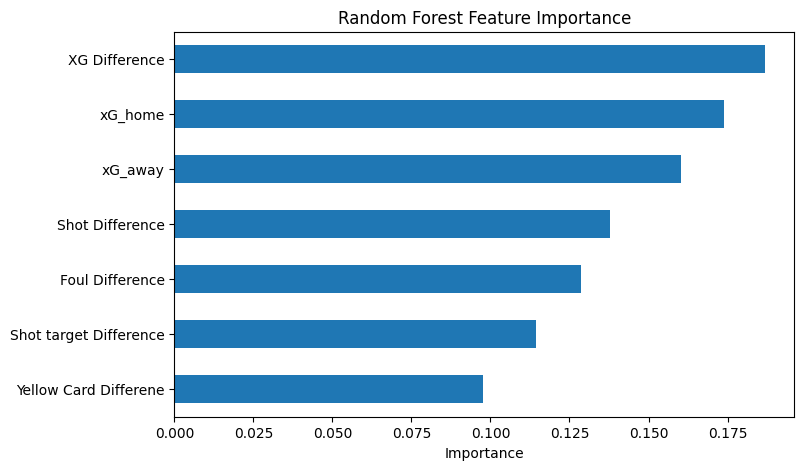

In [39]:
feat_imp.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

In [40]:
df.to_csv("/content/drive/MyDrive/football_analytics_project/epl_week2_baseline.csv", index=False)
print("Week 2 baseline dataset saved.")

Week 2 baseline dataset saved.


In [41]:
### ADVANCED FEATURE ENGINEERING.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
df = pd.read_csv("/content/drive/MyDrive/football_analytics_project/epl_clean_dataset.csv")
df = df.copy()
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,...,AY,Goal Difference,Shot Difference,Shot target Difference,Foul Difference,Yellow Card Differene,Home Win,xG_home,xG_away,total_goals
0,15/08/2025,Liverpool,Bournemouth,4,2,H,19,10,10,3,...,2,2,9,7,-3,-1,1,4.27,1.41,6
1,16/08/2025,Aston Villa,Newcastle,0,0,D,3,16,3,3,...,1,0,-13,0,2,0,0,1.20,1.59,0
2,16/08/2025,Brighton,Fulham,1,1,D,10,7,4,2,...,3,0,3,2,1,0,0,1.78,0.95,2
3,16/08/2025,Sunderland,West Ham,3,0,H,10,12,5,4,...,1,3,-2,1,-2,-1,1,2.15,1.84,3
4,16/08/2025,Tottenham,Burnley,3,0,H,16,14,6,4,...,0,3,2,2,6,0,1,2.70,1.90,3


In [43]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df = df.sort_values("Date").copy()

In [44]:
df["xG_home"] = (df["HST"] * 0.4) + ((df["HS"] - df["HST"]) * 0.03)
df["xG_away"] = (df["AST"] * 0.4) + ((df["AS"] - df["AST"]) * 0.03)

df["shot_acc_home"] = df["HST"] / df["HS"]
df["shot_acc_away"] = df["AST"] / df["AS"]

df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)

In [45]:

## CREATED POINTS FOR H AND A TEAMS


def get_home_points(results):
   if results == "H":
     return 3
   elif results == "D":
     return 1
   return 0

def get_away_points(results):
   if results == "A":
     return 3
   elif results == "D":
     return 1
   return 0


df["home_points"]= df["FTR"].apply(get_home_points)
df["away_points"]= df["FTR"].apply(get_away_points)

In [46]:
home_df = df[[
    "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "HS", "HST",
    "HF", "HY", "xG_home", "shot_acc_home", "home_points"
]].copy()

home_df.columns = [
    "Date", "Team", "Opponent", "GoalsFor", "GoalsAgainst", "Shots",
    "ShotsOnTarget", "Fouls", "YellowCards", "xG", "ShotAccuracy", "Points"
]

away_df = df[[
    "Date", "AwayTeam", "HomeTeam", "FTAG", "FTHG", "AS", "AST",
    "AF", "AY", "xG_away", "shot_acc_away", "away_points"
]].copy()

away_df.columns = [
    "Date", "Team", "Opponent", "GoalsFor", "GoalsAgainst", "Shots",
    "ShotsOnTarget", "Fouls", "YellowCards", "xG", "ShotAccuracy", "Points"
]

team_matches = pd.concat([home_df,away_df],ignore_index=True)
team_matches = team_matches.sort_values(["Team", "Date"]).copy()





In [47]:
team_matches["form_last5"] = (
    team_matches.groupby("Team")["Points"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

team_matches["goals_for_last5"] = (
    team_matches.groupby("Team")["GoalsFor"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

team_matches["goals_against_last5"] = (
    team_matches.groupby("Team")["GoalsAgainst"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

team_matches["xg_last5"] = (
    team_matches.groupby("Team")["xG"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

team_matches["shot_acc_last5"] = (
    team_matches.groupby("Team")["ShotAccuracy"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

In [48]:
home_features = team_matches[["Date","Team","form_last5","goals_for_last5","goals_against_last5","xg_last5","shot_acc_last5"]].copy()
home_features.columns = ["Date","HomeTeam","home_form_last5","home_goals_for_last5","home_goals_against_last5","home_xg_last5","home_shot_acc_last5"]

In [49]:
away_features = team_matches[["Date", "Team", "form_last5", "goals_for_last5","goals_against_last5", "xg_last5", "shot_acc_last5"]].copy()

away_features.columns = ["Date", "AwayTeam", "away_form_last5", "away_goals_for_last5","away_goals_against_last5", "away_xg_last5", "away_shot_acc_last5"]

In [50]:
print(home_features.head())
print(away_features.head())

           Date HomeTeam  home_form_last5  home_goals_for_last5  \
6    2023-08-12  Arsenal              NaN                   NaN   
1078 2023-08-21  Arsenal         3.000000              2.000000   
21   2023-08-26  Arsenal         3.000000              1.500000   
38   2023-09-03  Arsenal         2.333333              1.666667   
1106 2023-09-17  Arsenal         2.500000              2.000000   

      home_goals_against_last5  home_xg_last5  home_shot_acc_last5  
6                          NaN            NaN                  NaN  
1078                       1.0         3.0400             0.466667  
21                         0.5         2.2850             0.340476  
38                         1.0         3.0700             0.419967  
1106                       1.0         2.8925             0.388504  
           Date AwayTeam  away_form_last5  away_goals_for_last5  \
6    2023-08-12  Arsenal              NaN                   NaN   
1078 2023-08-21  Arsenal         3.000000        

In [51]:
df["Date"] = pd.to_datetime(df["Date"])
team_matches["Date"] = pd.to_datetime(team_matches["Date"])
home_features["Date"] = pd.to_datetime(home_features["Date"])
away_features["Date"] = pd.to_datetime(away_features["Date"])

In [52]:
df["HomeTeam"] = df["HomeTeam"].str.strip()
df["AwayTeam"] = df["AwayTeam"].str.strip()

home_features["HomeTeam"] = home_features["HomeTeam"].str.strip()
away_features["AwayTeam"] = away_features["AwayTeam"].str.strip()

In [53]:
df = pd.merge(df, home_features, on=["Date", "HomeTeam"], how="left")
df = pd.merge(df, away_features, on=["Date", "AwayTeam"], how="left")

In [54]:
print(df[[
    "Date", "HomeTeam", "AwayTeam",
    "home_form_last5", "away_form_last5",
    "home_xg_last5", "away_xg_last5"
]].head(50))

         Date          HomeTeam          AwayTeam  home_form_last5  \
0  2023-08-11           Burnley          Man City              NaN   
1  2023-08-12       Bournemouth          West Ham              NaN   
2  2023-08-12          Brighton             Luton              NaN   
3  2023-08-12           Everton            Fulham              NaN   
4  2023-08-12  Sheffield United    Crystal Palace              NaN   
5  2023-08-12         Newcastle       Aston Villa              NaN   
6  2023-08-12           Arsenal     Nott'm Forest              NaN   
7  2023-08-13         Brentford         Tottenham              NaN   
8  2023-08-13           Chelsea         Liverpool              NaN   
9  2023-08-14        Man United            Wolves              NaN   
10 2023-08-18     Nott'm Forest  Sheffield United         0.000000   
11 2023-08-19            Fulham         Brentford         3.000000   
12 2023-08-19         Liverpool       Bournemouth         1.000000   
13 2023-08-19       

In [55]:
rolling_cols = [
    "home_form_last5", "home_goals_for_last5", "home_goals_against_last5",
    "home_xg_last5", "home_shot_acc_last5",
    "away_form_last5", "away_goals_for_last5", "away_goals_against_last5",
    "away_xg_last5", "away_shot_acc_last5"
]

df[rolling_cols] = df[rolling_cols].fillna(0)

In [56]:
##COMPARATIVE FEATURES..

df["form_diff_last5"] = df["home_form_last5"] - df["away_form_last5"]
df["goals_for_diff_last5"] = df["home_goals_for_last5"] - df["away_goals_for_last5"]
df["goals_against_diff_last5"] = df["home_goals_against_last5"] - df["away_goals_against_last5"]
df["xg_diff_last5"] = df["home_xg_last5"] - df["away_xg_last5"]
df["shot_acc_diff_last5"] = df["home_shot_acc_last5"] - df["away_shot_acc_last5"]

In [57]:
df[[
    "Date", "HomeTeam", "AwayTeam",
    "home_form_last5", "away_form_last5",
    "form_diff_last5", "home_xg_last5", "away_xg_last5", "xg_diff_last5"
]].head(25)

,Date,HomeTeam,AwayTeam,home_form_last5,away_form_last5,form_diff_last5,home_xg_last5,away_xg_last5,xg_diff_last5
0,2023-08-11,Burnley,Man City,0.0,0.0,0.0,0.000,0.000,0.000
1,2023-08-12,Bournemouth,West Ham,0.0,0.0,0.0,0.000,0.000,0.000
2,2023-08-12,Brighton,Luton,0.0,0.0,0.0,0.000,0.000,0.000
3,2023-08-12,Everton,Fulham,0.0,0.0,0.0,0.000,0.000,0.000
4,2023-08-12,Sheffield United,Crystal Palace,0.0,0.0,0.0,0.000,0.000,0.000
5,2023-08-12,Newcastle,Aston Villa,0.0,0.0,0.0,0.000,0.000,0.000
6,2023-08-12,Arsenal,Nott'm Forest,0.0,0.0,0.0,0.000,0.000,0.000
7,2023-08-13,Brentford,Tottenham,0.0,0.0,0.0,0.000,0.000,0.000
8,2023-08-13,Chelsea,Liverpool,0.0,0.0,0.0,0.000,0.000,0.000
9,2023-08-14,Man United,Wolves,0.0,0.0,0.0,0.000,0.000,0.000


In [58]:
df.to_csv("/content/drive/MyDrive/football_analytics_project/epl_week3_features.csv", index=False)
print("Week 3 dataset saved.")

Week 3 dataset saved.


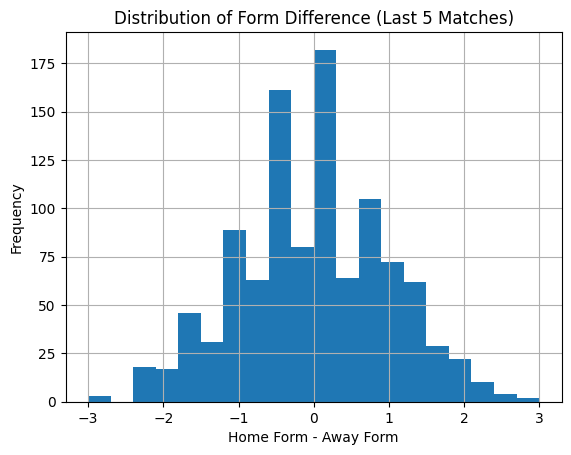

In [59]:
### VIZUALIZATIONS

df["form_diff_last5"].hist(bins=20)
plt.title("Distribution of Form Difference (Last 5 Matches)")
plt.xlabel("Home Form - Away Form")
plt.ylabel("Frequency")
plt.show()

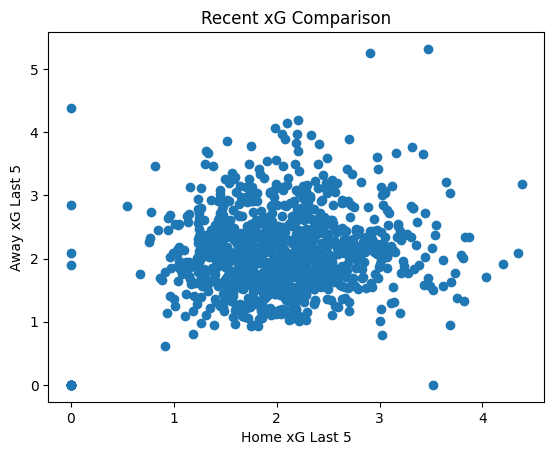

In [60]:
plt.scatter(df["home_xg_last5"], df["away_xg_last5"])
plt.xlabel("Home xG Last 5")
plt.ylabel("Away xG Last 5")
plt.title("Recent xG Comparison")
plt.show()

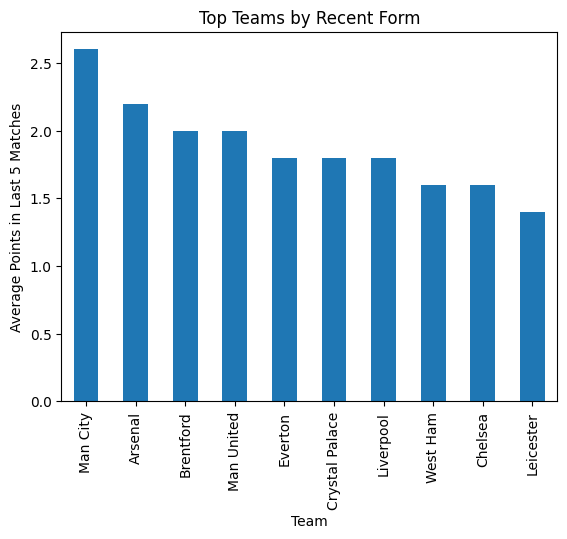

In [61]:
latest_form = team_matches.groupby("Team")["form_last5"].last().sort_values(ascending=False)
latest_form.head(10).plot(kind="bar")
plt.title("Top Teams by Recent Form")
plt.ylabel("Average Points in Last 5 Matches")
plt.show()

In [62]:
## IMPROVED MODEL TUNING..

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [63]:
df = pd.read_csv("/content/drive/MyDrive/football_analytics_project/epl_week3_features.csv")
df = df.copy()
df.head(40)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,...,away_form_last5,away_goals_for_last5,away_goals_against_last5,away_xg_last5,away_shot_acc_last5,form_diff_last5,goals_for_diff_last5,goals_against_diff_last5,xg_diff_last5,shot_acc_diff_last5
0,2023-08-11,Burnley,Man City,0,3,A,6,17,1,8,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2023-08-12,Bournemouth,West Ham,1,1,D,14,16,5,3,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2023-08-12,Brighton,Luton,4,1,H,27,9,12,3,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2023-08-12,Everton,Fulham,0,1,A,19,9,9,2,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2023-08-12,Sheffield United,Crystal Palace,0,1,A,8,24,1,8,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,2023-08-12,Newcastle,Aston Villa,5,1,H,17,16,13,6,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,2023-08-12,Arsenal,Nott'm Forest,2,1,H,15,6,7,2,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,2023-08-13,Brentford,Tottenham,2,2,D,11,18,6,6,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,2023-08-13,Chelsea,Liverpool,1,1,D,10,13,4,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,2023-08-14,Man United,Wolves,1,0,H,15,23,3,6,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [64]:
features_week4 = [
    "home_form_last5",
    "away_form_last5",
    "form_diff_last5",
    "home_goals_for_last5",
    "away_goals_for_last5",
    "goals_for_diff_last5",
    "home_goals_against_last5",
    "away_goals_against_last5",
    "goals_against_diff_last5",
    "home_xg_last5",
    "away_xg_last5",
    "xg_diff_last5",
    "home_shot_acc_last5",
    "away_shot_acc_last5",
    "shot_acc_diff_last5"
]

X = df[features_week4]
y = df["FTR"]

In [65]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['A' 'D' 'H']


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [67]:
lr = LogisticRegression(max_iter=3000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Week 4 Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Week 4 Logistic Regression Accuracy: 0.5330188679245284
              precision    recall  f1-score   support

           A       0.53      0.57      0.55        70
           D       0.00      0.00      0.00        51
           H       0.54      0.80      0.64        91

    accuracy                           0.53       212
   macro avg       0.35      0.46      0.40       212
weighted avg       0.40      0.53      0.46       212



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Week 4 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Week 4 Random Forest Accuracy: 0.44339622641509435
              precision    recall  f1-score   support

           A       0.44      0.44      0.44        70
           D       0.10      0.04      0.06        51
           H       0.50      0.67      0.58        91

    accuracy                           0.44       212
   macro avg       0.35      0.38      0.36       212
weighted avg       0.38      0.44      0.41       212



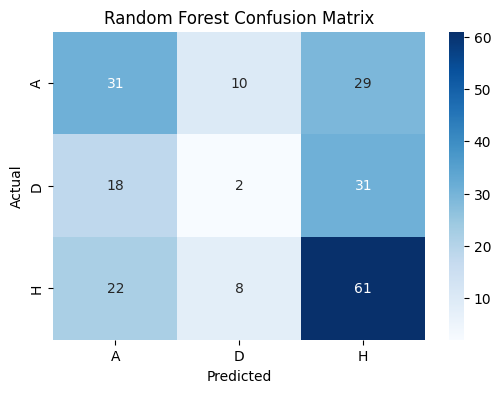

In [69]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [70]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best CV score: 0.5094395575938317


In [71]:
best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Tuned Random Forest Accuracy: 0.5283018867924528
              precision    recall  f1-score   support

           A       0.55      0.53      0.54        70
           D       0.00      0.00      0.00        51
           H       0.52      0.82      0.64        91

    accuracy                           0.53       212
   macro avg       0.36      0.45      0.39       212
weighted avg       0.40      0.53      0.45       212



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


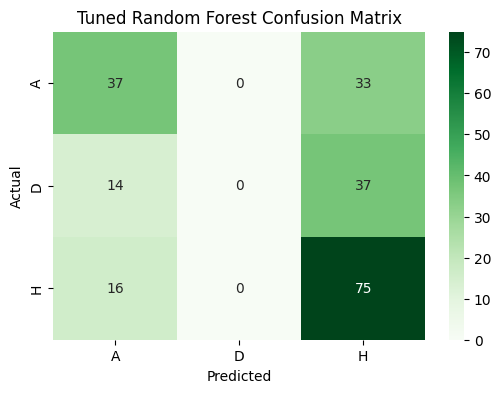

In [72]:
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [73]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.533019
1,Random Forest,0.443396
2,Tuned Random Forest,0.528302


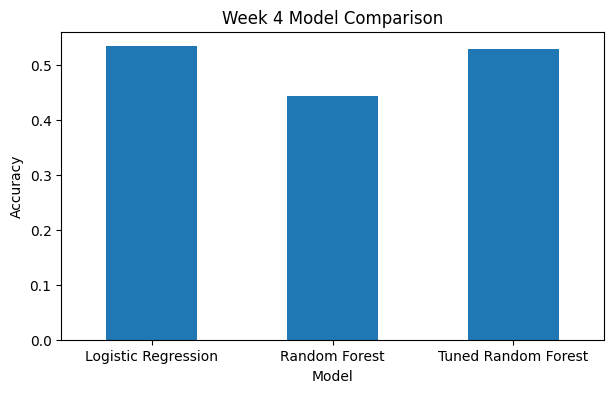

In [74]:
results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    figsize=(7, 4)
)

plt.title("Week 4 Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

In [75]:
importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=features_week4).sort_values(ascending=False)

feat_imp

,0
xg_diff_last5,0.124683
home_xg_last5,0.096396
form_diff_last5,0.093271
goals_against_diff_last5,0.073181
away_xg_last5,0.071352
goals_for_diff_last5,0.067858
shot_acc_diff_last5,0.063856
home_goals_for_last5,0.061584
away_form_last5,0.061294
home_shot_acc_last5,0.060661


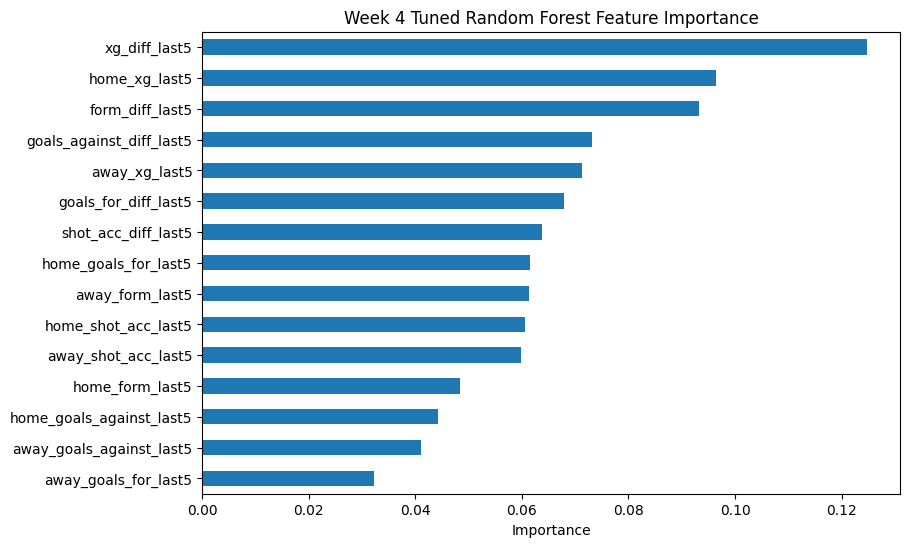

In [76]:
feat_imp.sort_values().plot(kind="barh", figsize=(9, 6))
plt.title("Week 4 Tuned Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

In [77]:
df["FTR"].value_counts()

,count
FTR,
H,455
A,349
D,256


In [78]:
df["FTR"].value_counts(normalize=True)

,proportion
FTR,
H,0.429245
A,0.329245
D,0.241509


In [79]:
df["home_win"] = (df["FTR"] == "H").astype(int)

X_bin = df[features_week4]
y_bin = df["home_win"]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

rf_bin = RandomForestClassifier(n_estimators=300, random_state=42)
rf_bin.fit(X_train_b, y_train_b)

y_pred_bin = rf_bin.predict(X_test_b)

print("Binary Random Forest Accuracy:", accuracy_score(y_test_b, y_pred_bin))
print(classification_report(y_test_b, y_pred_bin))

Binary Random Forest Accuracy: 0.6415094339622641
              precision    recall  f1-score   support

           0       0.65      0.79      0.72       121
           1       0.62      0.44      0.51        91

    accuracy                           0.64       212
   macro avg       0.63      0.62      0.61       212
weighted avg       0.64      0.64      0.63       212



In [80]:
df.to_csv("/content/drive/MyDrive/football_analytics_project/epl_week4_model_ready.csv", index=False)
print("Week 4 dataset saved.")

Week 4 dataset saved.


In [81]:
###  SHAP START




!pip install shap


In [82]:
import shap


In [83]:
explainer = shap.TreeExplainer(best_rf)

In [84]:
shap_values = explainer.shap_values(X_test)

In [85]:
print("X_test shape:", X_test.shape)
print("Classes:", le.classes_)

if isinstance(shap_values, list):
    print("SHAP returned a list")
    for i, sv in enumerate(shap_values):
        print(f"Class {i} shape:", np.array(sv).shape)
else:
    print("SHAP returned an array")
    print("SHAP shape:", np.array(shap_values).shape)

X_test shape: (212, 15)
Classes: ['A' 'D' 'H']
SHAP returned an array
SHAP shape: (212, 15, 3)


In [86]:
print(le.classes_)

['A' 'D' 'H']


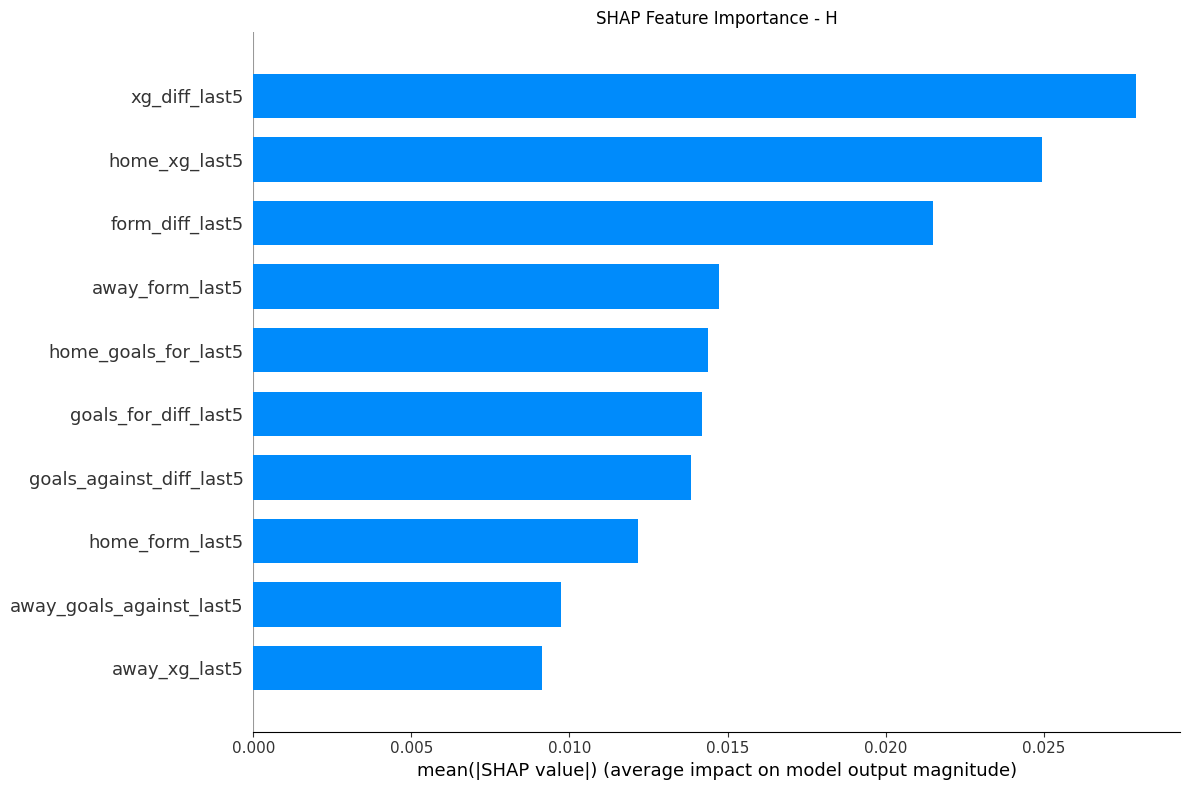

In [87]:
class_index = 2   # example for H

sv_class = shap_values[:, :, class_index]

plt.figure(figsize=(12, 8))
shap.summary_plot(
    sv_class,
    X_test,
    plot_type="bar",
    plot_size=(12, 8),
    max_display=10,
    show=False
)
plt.title(f"SHAP Feature Importance - {le.classes_[class_index]}")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/football_analytics_project/shap_home_win_bar.png", dpi=300, bbox_inches="tight")

plt.show()


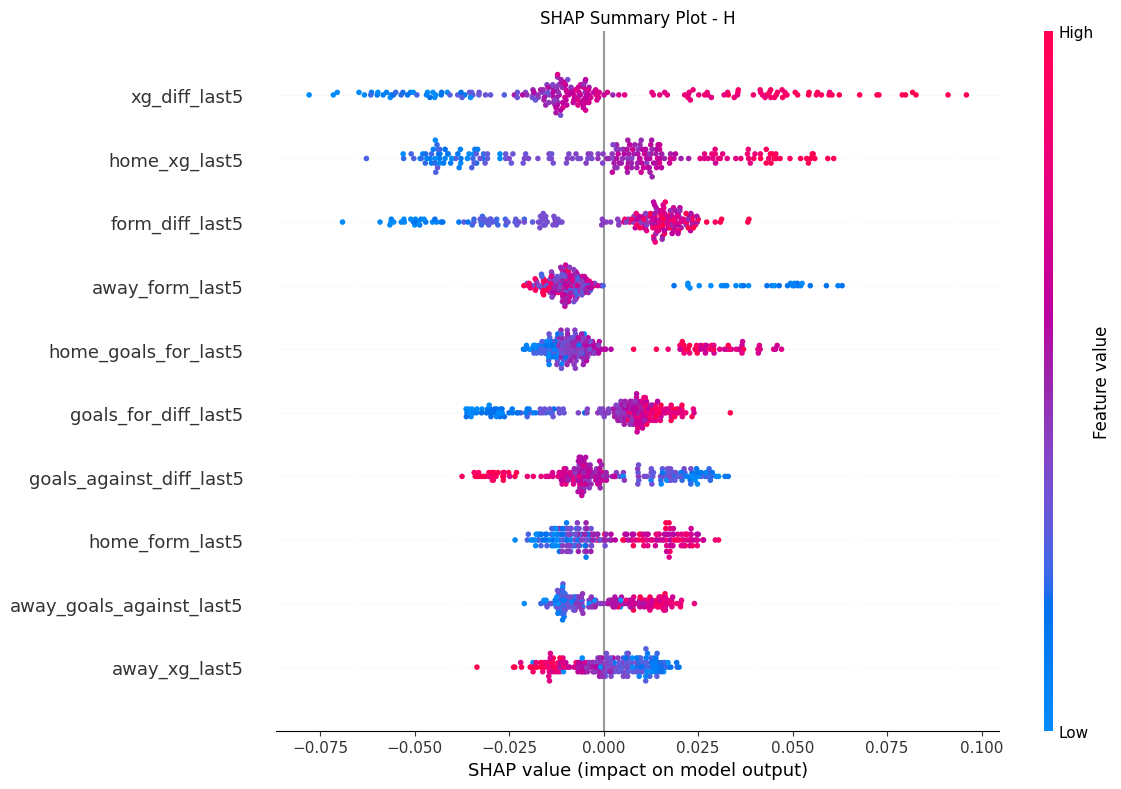

In [88]:
plt.figure(figsize=(12, 8))
shap.summary_plot(
    sv_class,
    X_test,
    plot_size=(12, 8),
    max_display=10,
    show=False
)
plt.title(f"SHAP Summary Plot - {le.classes_[class_index]}")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/football_analytics_project/shap_home_win_summary.png", dpi=300, bbox_inches="tight")

plt.show()



In [89]:
import joblib

joblib.dump(best_rf, "/content/drive/MyDrive/football_analytics_project/best_rf_model.pkl")
print("Model saved")

Model saved
